In [1]:
import pandas as pd

data = pd.read_csv("2Probe.csv")
data.head()


,row_type,measurement_index,target_x_mm,target_y_mm,target_force_N,actual_x_mm,actual_y_mm,position_time_s,actual_force_N,force_time_s,...,eit_55,eit_56,eit_57,eit_58,eit_59,eit_60,eit_61,eit_62,eit_63,eit_time_s
0,baseline,NaN,NaN,NaN,NaN,NaN,NaN,0.107663,NaN,NaN,...,0.1752,0.1537,0.1551,0.1547,0.1462,0.1514,0.2250,0.1490,0.1771,0.107663
1,baseline,1.0,104.435897,14.794872,4.0,104.44,14.79,124.801230,0.0000,NaN,...,0.1766,0.1543,0.1560,0.1558,0.1471,0.1545,0.2193,0.1507,0.1786,124.811329
2,contact,1.0,104.435897,14.794872,4.0,104.44,14.79,124.801230,4.4018,146.863373,...,0.1644,0.1540,0.1556,0.1554,0.1463,0.1543,0.2189,0.1587,0.1648,147.915774
3,baseline,2.0,102.794872,17.968661,2.0,102.79,17.97,149.756625,0.0000,NaN,...,0.1872,0.1557,0.1578,0.1573,0.1485,0.1569,0.2233,0.1590,0.1900,149.779838
4,contact,2.0,102.794872,17.968661,2.0,102.79,17.97,149.756625,2.0840,160.401602,...,0.1317,0.1551,0.1529,0.1564,0.1490,0.1618,0.2275,0.1555,0.1344,161.430477


In [2]:
import re
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt


LEFT_HEIGHT_MM = 20.0
RIGHT_HEIGHT_MM = 15.0
GAP_MM = 60.0
NUM_TAXELS = 64
GRID_COLS = 8
GRID_ROWS = NUM_TAXELS // GRID_COLS


def eit_columns(frame):
    """Return eit_ columns in numeric channel order."""
    cols = []
    for col in frame.columns:
        match = re.fullmatch(r"eit_(\d+)", col)
        if match:
            cols.append((int(match.group(1)), col))
    return [col for _, col in sorted(cols)]


def taxel_label_grid():
    """Taxel 1 is bottom-left, 1-8 run left-to-right, 9 is above 1."""
    return np.arange(1, NUM_TAXELS + 1).reshape(GRID_ROWS, GRID_COLS)


def contact_rows(frame):
    cache = taxel_cache(frame)
    return cache["contacts"].copy()


def taxel_cache(frame):
    """Build contact/baseline deltas once and reuse them for plotting."""
    cache = frame.attrs.get("taxel_imager_cache")
    if cache is not None:
        return cache

    cols = eit_columns(frame)
    expected = GRID_ROWS * GRID_COLS
    if len(cols) != expected:
        raise ValueError(f"Expected {expected} taxel channels, found {len(cols)}.")

    rows = frame.copy()
    rows["row_type"] = rows["row_type"].astype(str).str.lower()
    rows = rows[rows["measurement_index"].notna()].copy()
    rows["measurement_index"] = rows["measurement_index"].astype(int)

    contacts = rows[rows["row_type"].eq("contact")].copy()
    baselines = rows[rows["row_type"].eq("baseline")].copy()
    if contacts.empty:
        raise ValueError("No contact rows found.")
    if baselines.empty:
        raise ValueError("No baseline rows found.")

    contacts = contacts.drop_duplicates("measurement_index").set_index("measurement_index", drop=False)
    baselines = baselines.drop_duplicates("measurement_index").set_index("measurement_index", drop=False)
    common_index = contacts.index.intersection(baselines.index).sort_values()
    if common_index.empty:
        raise ValueError("No contact rows have a matching baseline measurement_index.")

    contacts = contacts.loc[common_index]
    baselines = baselines.loc[common_index]
    contact_values = contacts[cols].astype(float).to_numpy()
    baseline_values = baselines[cols].astype(float).to_numpy()
    deltas = contact_values - baseline_values

    cache = {
        "eit_columns": cols,
        "contacts": contacts.reset_index(drop=True),
        "contact_by_measurement": contacts,
        "measurement_indices": common_index.to_numpy(dtype=int),
        "delta_by_measurement": {
            int(measurement_index): delta.reshape(GRID_ROWS, GRID_COLS)
            for measurement_index, delta in zip(common_index, deltas)
        },
        "vlim": float(np.nanmax(np.abs(deltas))) if deltas.size else 1.0,
    }
    if not cache["vlim"]:
        cache["vlim"] = 1.0

    frame.attrs["taxel_imager_cache"] = cache
    return cache


def paired_contact_delta(frame, measurement_index=None):
    """Use contact minus the baseline with the same measurement_index."""
    cache = taxel_cache(frame)
    contacts = cache["contact_by_measurement"]
    if measurement_index is None:
        measurement_index = int(cache["measurement_indices"][0])
    measurement_index = int(measurement_index)

    if measurement_index not in cache["delta_by_measurement"]:
        raise ValueError(f"No matched contact/baseline row found for measurement_index={measurement_index}.")

    grid = cache["delta_by_measurement"][measurement_index]
    label_grid = taxel_label_grid()
    contact = contacts.loc[measurement_index]
    return grid, label_grid, contact


def trapezium_edges(rows=GRID_ROWS, cols=GRID_COLS):
    """Create pcolormesh corner coordinates with left/right edges centre-aligned."""
    x_edges = np.linspace(0.0, GAP_MM, cols + 1)
    t = x_edges / GAP_MM
    height = (1.0 - t) * LEFT_HEIGHT_MM + t * RIGHT_HEIGHT_MM
    centre_y = LEFT_HEIGHT_MM / 2.0
    bottom = centre_y - height / 2.0
    top = centre_y + height / 2.0

    x = np.tile(x_edges, (rows + 1, 1))
    y_fraction = np.linspace(0.0, 1.0, rows + 1)[:, None]
    y = bottom[None, :] + y_fraction * (top - bottom)[None, :]
    return x, y


def cell_centres(x_edges, y_edges):
    x = 0.25 * (x_edges[:-1, :-1] + x_edges[:-1, 1:] + x_edges[1:, :-1] + x_edges[1:, 1:])
    y = 0.25 * (y_edges[:-1, :-1] + y_edges[:-1, 1:] + y_edges[1:, :-1] + y_edges[1:, 1:])
    return x, y


def contact_origin(frame, x_col="actual_x_mm", y_col="actual_y_mm"):
    contacts = contact_rows(frame)
    return float(contacts[x_col].min()), float(contacts[y_col].min())


def origin_contact_measurement_index(frame, x_col="actual_x_mm", y_col="actual_y_mm"):
    """Return a contact whose probe position is at the mapping origin."""
    contacts = contact_rows(frame)
    origin_x, origin_y = contact_origin(frame, x_col=x_col, y_col=y_col)
    at_origin = contacts[
        np.isclose(contacts[x_col].astype(float), origin_x)
        & np.isclose(contacts[y_col].astype(float), origin_y)
    ]
    if at_origin.empty:
        dx = contacts[x_col].astype(float) - origin_x
        dy = contacts[y_col].astype(float) - origin_y
        at_origin = contacts.loc[[((dx ** 2) + (dy ** 2)).idxmin()]]
    return int(at_origin.sort_values("measurement_index").iloc[0]["measurement_index"])


def contact_position_on_mesh(contact, frame, cell_x, cell_y, x_col="actual_x_mm", y_col="actual_y_mm"):
    """Anchor the smallest contact x/y at the bottom-left taxel centre."""
    origin_x, origin_y = contact_origin(frame, x_col=x_col, y_col=y_col)
    bottom_left_x = float(cell_x[0, 0])
    bottom_left_y = float(cell_y[0, 0])
    x = float(contact[x_col]) - origin_x + bottom_left_x
    y = float(contact[y_col]) - origin_y + bottom_left_y
    return x, y, origin_x, origin_y


def global_heatmap_limit(frame):
    return taxel_cache(frame)["vlim"]


def plot_contact_heatmap(
    frame,
    measurement_index,
    ax=None,
    vlim=None,
    show_colorbar=True,
    show_contact=True,
    x_col="actual_x_mm",
    y_col="actual_y_mm",
):
    """Plot one baseline-subtracted two-probe contact on the trapezium taxel mesh."""
    heatmap, taxel_labels, selected_contact = paired_contact_delta(frame, measurement_index=measurement_index)
    x_edges, y_edges = trapezium_edges()
    cell_x, cell_y = cell_centres(x_edges, y_edges)

    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 4))
    else:
        fig = ax.figure

    limit = float(vlim if vlim is not None else (np.nanmax(np.abs(heatmap)) or 1.0))
    mesh = ax.pcolormesh(
        x_edges,
        y_edges,
        heatmap,
        cmap="RdBu_r",
        vmin=-limit,
        vmax=limit,
        edgecolors="black",
        linewidth=0.7,
        shading="flat",
    )

    left_bottom, left_top = y_edges[0, 0], y_edges[-1, 0]
    right_bottom, right_top = y_edges[0, -1], y_edges[-1, -1]
    ax.plot(
        [0, GAP_MM, GAP_MM, 0, 0],
        [left_bottom, right_bottom, right_top, left_top, left_bottom],
        color="black",
        linewidth=2,
    )
    ax.axhline(LEFT_HEIGHT_MM / 2.0, color="black", linestyle=":", linewidth=1, alpha=0.5)

    contact_x = contact_y = None
    origin_x = origin_y = None
    if show_contact:
        contact_x, contact_y, origin_x, origin_y = contact_position_on_mesh(
            selected_contact,
            frame,
            cell_x,
            cell_y,
            x_col=x_col,
            y_col=y_col,
        )
        ax.scatter(
            [contact_x],
            [contact_y],
            s=95,
            marker="x",
            c="black",
            linewidths=2.4,
            label="Contact centre",
            zorder=5,
        )
        ax.scatter([contact_x], [contact_y], s=130, facecolors="none", edgecolors="white", linewidths=2.0, zorder=4)
        ax.legend(loc="upper right", fontsize=8, frameon=True)

    ax.set_xticks(cell_x[0])
    ax.set_xticklabels([str(i) for i in range(1, GRID_COLS + 1)])
    ax.set_yticks(cell_y[:, 0])
    ax.set_yticklabels([str(i) for i in range(1, NUM_TAXELS + 1, GRID_COLS)])
    ax.set_aspect("equal", adjustable="box")
    ax.set_xlim(-2, GAP_MM + 2)
    ax.set_ylim(min(y_edges.ravel()) - 2, max(y_edges.ravel()) + 2)
    ax.set_xlabel("Taxel column: 1-8 left to right")
    ax.set_ylabel("Taxel row start: 1, 9, 17, ... bottom to top")
    ax.set_title(
        "Trapezium taxel heatmap "
        f"(measurement {int(selected_contact['measurement_index'])}, "
        f"force {selected_contact['actual_force_N']:.2f} N, "
        f"contact [{contact_x:.2f}, {contact_y:.2f}] mm)"
    )

    if show_colorbar:
        fig.colorbar(mesh, ax=ax, label="Contact - matching baseline EIT signal")

    metadata = {
        "heatmap": heatmap,
        "taxel_labels": taxel_labels,
        "contact": selected_contact,
        "contact_x_mm": contact_x,
        "contact_y_mm": contact_y,
        "origin_x_mm": origin_x,
        "origin_y_mm": origin_y,
        "mesh": mesh,
    }
    return fig, ax, metadata


def plot_all_contacts(frame, output_dir="TaxelHeatmaps", show=False, dpi=160):
    """Save one trapezium heatmap per contact row."""
    output_path = Path(output_dir)
    output_path.mkdir(parents=True, exist_ok=True)
    cache = taxel_cache(frame)
    vlim = cache["vlim"]
    saved_files = []

    for measurement_index in cache["measurement_indices"]:
        fig, ax, metadata = plot_contact_heatmap(
            frame,
            measurement_index=int(measurement_index),
            vlim=vlim,
            show_colorbar=True,
            show_contact=True,
        )
        contact = metadata["contact"]
        force_label = f"{float(contact['actual_force_N']):.2f}".replace(".", "p")
        filename = f"measurement_{int(measurement_index):03d}_force_{force_label}N.png"
        save_path = output_path / filename
        fig.savefig(save_path, dpi=dpi, bbox_inches="tight")
        saved_files.append(save_path)
        if show:
            plt.show()
        else:
            plt.close(fig)

    return saved_files


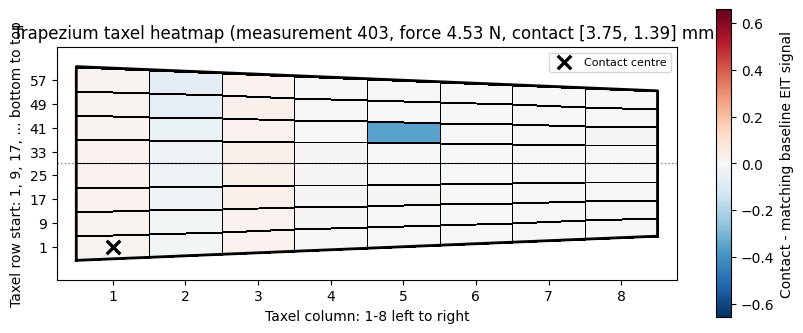

Previewed origin measurement_index: 403
Raw contact location: (47.0, 13.0)
Mesh contact location: (3.75, 1.38671875)
Contact origin from minimum actual x/y: (47.0, 13.0)
Bottom-left taxel centre should match mesh contact location for an origin probe.
Taxel grid follows row-major channel order:
bottom row taxels: [1, 2, 3, 4, 5, 6, 7, 8]
bottom-left plotted taxel: 1
taxel above bottom-left: 9
top-left plotted taxel: 57


In [ ]:
# Preview a contact whose probe was placed at the mapping origin.
# Origin rule: min actual_x_mm and min actual_y_mm are the centre of the bottom-left taxel.
origin_measurement_index = origin_contact_measurement_index(data)
fig, ax, preview = plot_contact_heatmap(data, measurement_index=origin_measurement_index, vlim=global_heatmap_limit(data))
plt.show()

print("Previewed origin measurement_index:", origin_measurement_index)
print("Raw contact location:", (float(preview["contact"]["actual_x_mm"]), float(preview["contact"]["actual_y_mm"])))
print("Mesh contact location:", (preview["contact_x_mm"], preview["contact_y_mm"]))
print("Contact origin from minimum actual x/y:", (preview["origin_x_mm"], preview["origin_y_mm"]))
print("Bottom-left taxel centre should match mesh contact location for an origin probe.")
print("Taxel grid follows row-major channel order:")
print("bottom row taxels:", preview["taxel_labels"][0].tolist())
print("bottom-left plotted taxel:", int(preview["taxel_labels"][0, 0]))
print("taxel above bottom-left:", int(preview["taxel_labels"][1, 0]))
print("top-left plotted taxel:", int(preview["taxel_labels"][-1, 0]))

RUN_ALL_CONTACTS = True
if RUN_ALL_CONTACTS:
    saved_heatmaps = plot_all_contacts(data, output_dir="TaxelHeatmaps", show=False)
    print(f"Saved {len(saved_heatmaps)} contact heatmaps to {saved_heatmaps[0].parent}")
    print("First saved file:", saved_heatmaps[0])
    print("Last saved file:", saved_heatmaps[-1])
